# MaskCLIP Baseline — CLIP ViT-B/16

Runs the same zero-shot segmentation eval as `02_b0_benchmark.ipynb`, but on the
**original CLIP ViT-B/16** model with MaskCLIP-style and SCLIP-style patch extraction.

Purpose: validate the eval pipeline against published numbers.
- MaskCLIP paper (Zhou et al.): VOC ≈ 22.4%, COCO-Stuff-27 ≈ 13.2% (CLIP-B/16)
- SCLIP paper (Wang et al.):    VOC ≈ 35.6%, COCO-Stuff-27 ≈ 22.4% (CLIP-B/16)

Key differences from the SigLIP B0 notebook:
- Model: `openai/clip-vit-base-patch16` (224×224, 14×14=196 patches)
- Vision features: `last_hidden_state[:, 1:, :]` (skip CLS) → `visual_projection` (768→512)
- Text features: `model.get_text_features()` (trained projection, 512-dim)
- No random-init head issue — CLIP's projection heads are fully trained

In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import os, types, getpass
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

from transformers import CLIPModel, CLIPProcessor
import torchvision.datasets as tvd

if not os.environ.get('HF_TOKEN'):
    os.environ['HF_TOKEN'] = getpass.getpass('HF token (read scope): ')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

/Users/siddharthraj/Documents/my-projects/region-grounded/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [2]:
# ── 2. Load CLIP ViT-B/16 ─────────────────────────────────────────────────────
MODEL_ID   = 'openai/clip-vit-base-patch16'
EVAL_SIZE  = 224    # CLIP native resolution
PATCH_SIZE = 16
N_SIDE     = EVAL_SIZE // PATCH_SIZE   # 14
N_PATCHES  = N_SIDE ** 2              # 196
TEMPLATE   = 'a photo of a {}'

processor = CLIPProcessor.from_pretrained(MODEL_ID)
model     = CLIPModel.from_pretrained(MODEL_ID).to(DEVICE).eval()

# Sanity: confirm patch count
dummy = torch.zeros(1, 3, EVAL_SIZE, EVAL_SIZE, device=DEVICE)
with torch.no_grad():
    vout = model.vision_model(pixel_values=dummy)
# last_hidden_state: (B, 1+N_PATCHES, D) — index 0 is CLS
assert vout.last_hidden_state.shape[1] == 1 + N_PATCHES, \
    f'Unexpected token count: {vout.last_hidden_state.shape[1]}'
FEAT_DIM  = vout.last_hidden_state.shape[2]   # 768
PROJ_DIM  = model.visual_projection.out_features  # 512

print(f'Model       : {MODEL_ID}')
print(f'Patch grid  : {N_SIDE}×{N_SIDE} = {N_PATCHES} patches')
print(f'Encoder dim : {FEAT_DIM}')
print(f'Proj dim    : {PROJ_DIM}  (contrastive space)')
print(f'visual_projection: {model.visual_projection}')

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 71017.31it/s]


Model       : openai/clip-vit-base-patch16
Patch grid  : 14×14 = 196 patches
Encoder dim : 768
Proj dim    : 512  (contrastive space)
visual_projection: Linear(in_features=768, out_features=512, bias=False)


In [3]:
# ── 3. Patch extraction (three methods) ───────────────────────────────────────
#
# CLIP has no untrained head issue (unlike SigLIP + transformers 5.x).
# vision_model.last_hidden_state = (B, 1+N, D) with post_layernorm applied.
# Index 0 is the CLS token; indices 1: are patch tokens.
# visual_projection (768→512) maps into the contrastive embedding space.
#
# Extraction variants:
#   standard  — normal attention, patch tokens + visual_projection
#   maskclip  — last attention bypassed: output = v_proj(x) @ W_out
#               ("Extract Free Dense Labels from CLIP", Zhou et al. 2021)
#   sclip     — last attention uses K as both Q and K (symmetric attention)
#               (SCLIP, Wang et al. 2023)
#
# transformers 5.x CLIPAttention.forward accepts **kwargs — custom forwards
# must also accept them.

def _maskclip_attn_fwd(self, hidden_states, attention_mask=None, **kwargs):
    """MaskCLIP: skip attention aggregation, project V through out_proj."""
    return self.out_proj(self.v_proj(hidden_states)), None


def _sclip_attn_fwd(self, hidden_states, attention_mask=None, **kwargs):
    """SCLIP: use K as both Q and K — symmetric (K @ K^T) attention."""
    B, N, C = hidden_states.shape
    head_dim = C // self.num_heads
    scale    = head_dim ** -0.5
    k = self.k_proj(hidden_states).reshape(B, N, self.num_heads, head_dim).transpose(1, 2)
    v = self.v_proj(hidden_states).reshape(B, N, self.num_heads, head_dim).transpose(1, 2)
    attn = F.softmax((k @ k.transpose(-2, -1)) * scale, dim=-1)
    out  = (attn @ v).transpose(1, 2).reshape(B, N, C)
    return self.out_proj(out), None


def extract_patch_features(model, pixel_values, method='standard'):
    """
    Returns L2-normalised patch features in the contrastive space.
    Shape: (B, N_PATCHES, PROJ_DIM)

    Pipeline:
      pixel_values → vision_model (with optional attention swap)
      → last_hidden_state[:, 1:, :]  (skip CLS)
      → visual_projection            (768 → 512)
      → L2 normalise
    """
    last_attn = model.vision_model.encoder.layers[-1].self_attn
    orig_fwd  = last_attn.forward

    if method == 'maskclip':
        last_attn.forward = types.MethodType(_maskclip_attn_fwd, last_attn)
    elif method == 'sclip':
        last_attn.forward = types.MethodType(_sclip_attn_fwd, last_attn)
    elif method != 'standard':
        raise ValueError(f'Unknown method: {method}')

    try:
        with torch.no_grad():
            vout  = model.vision_model(pixel_values=pixel_values)
            patch = vout.last_hidden_state[:, 1:, :]   # (B, N, D) — skip CLS
            proj  = model.visual_projection(patch)      # (B, N, 512)
        return F.normalize(proj, dim=-1)
    finally:
        if method != 'standard':
            last_attn.forward = orig_fwd


def encode_text_classes(model, processor, class_names, device):
    """Encode class prompts → L2-normalised (n_cls, 512) in contrastive space.

    In transformers 5.x, model.get_text_features() returns a model output
    object rather than a plain tensor. Use text_model + text_projection directly.
    """
    prompts = [TEMPLATE.format(c) for c in class_names]
    inputs  = processor(text=prompts, return_tensors='pt', padding=True).to(device)
    with torch.no_grad():
        # text_model.pooler_output = EOS token after layer norm (n_cls, 768)
        pooled = model.text_model(**inputs).pooler_output
        feats  = model.text_projection(pooled)   # (n_cls, 512)
    return F.normalize(feats, dim=-1)


print('Extraction methods defined: standard, maskclip, sclip')

Extraction methods defined: standard, maskclip, sclip


In [4]:
# ── 4. Smoke test ─────────────────────────────────────────────────────────────
test_img = PILImage.fromarray(np.random.randint(0, 255, (300, 400, 3), dtype=np.uint8))
inputs   = processor(images=test_img, return_tensors='pt').to(DEVICE)

print(f'Processor output shape: {tuple(inputs["pixel_values"].shape)}')
print(f'{"Method":12s}  {"shape":22s}  {"mean_norm":10s}')
for method in ['standard', 'maskclip', 'sclip']:
    feats = extract_patch_features(model, inputs['pixel_values'], method)
    norms = feats.norm(dim=-1)
    print(f'{method:12s}  {str(tuple(feats.shape)):22s}  {norms.mean().item():.4f}')

# Three methods must produce different outputs
f_std = extract_patch_features(model, inputs['pixel_values'], 'standard')
f_msk = extract_patch_features(model, inputs['pixel_values'], 'maskclip')
f_scl = extract_patch_features(model, inputs['pixel_values'], 'sclip')
assert not torch.allclose(f_std, f_msk), 'standard == maskclip!'
assert not torch.allclose(f_std, f_scl), 'standard == sclip!'
print('\nAll three methods produce distinct outputs ✓')

# Check CLIP similarity range on a real prompt
txt = encode_text_classes(model, processor, ['cat', 'dog', 'car'], DEVICE)
sim = f_std[0] @ txt.T   # (196, 3)
print(f'\nCLIP cosine-sim range (random image vs 3 classes): [{sim.min():.3f}, {sim.max():.3f}]')
print('(CLIP sims are much larger than SigLIP raw-encoder sims)')

Processor output shape: (1, 3, 224, 224)
Method        shape                   mean_norm 
standard      (1, 196, 512)           1.0000
maskclip      (1, 196, 512)           1.0000
sclip         (1, 196, 512)           1.0000

All three methods produce distinct outputs ✓

CLIP cosine-sim range (random image vs 3 classes): [-0.208, 0.018]
(CLIP sims are much larger than SigLIP raw-encoder sims)


In [5]:
# ── 5. VOC setup + eval utilities ────────────────────────────────────────────
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor',
]

VOC_ROOT = Path('/tmp/voc')
VOC_ROOT.mkdir(exist_ok=True)
voc_val  = tvd.VOCSegmentation(
    root=str(VOC_ROOT), year='2012', image_set='val', download=True
)
print(f'VOC 2012 val: {len(voc_val)} images')

VOC_IGNORE = 255


def predict_segmentation(model, processor, pil_image, text_feats,
                         method, tau_seg, n_classes_fg, device):
    orig_w, orig_h = pil_image.size
    pix = processor(images=pil_image, return_tensors='pt').pixel_values.to(device)

    patch_feats = extract_patch_features(model, pix, method)  # (1, N, 512)
    sim = patch_feats[0] @ text_feats.T                       # (N, n_fg)

    sim_hw = sim.reshape(N_SIDE, N_SIDE, n_classes_fg)
    sim_up = F.interpolate(
        sim_hw.permute(2, 0, 1).unsqueeze(0).float(),
        size=(orig_h, orig_w), mode='bilinear', align_corners=False
    ).squeeze(0).permute(1, 2, 0)                             # (H, W, n_fg)

    max_sim, pred = sim_up.max(dim=-1)
    pred = pred + 1                       # 1-indexed fg
    pred[max_sim < tau_seg] = 0           # background
    return pred.cpu().numpy().astype(np.int64)


def accumulated_miou(tp, fp, fn, present_mask):
    iou = tp / (tp + fp + fn).clamp(min=1e-6)
    return iou[present_mask].mean().item() * 100, iou.cpu().numpy() * 100


def eval_voc(model, processor, voc_dataset, voc_classes, method,
             tau_seg, device, max_images=None, desc='VOC eval'):
    n_fg  = len(voc_classes)
    n_cls = n_fg + 1
    n     = min(max_images or len(voc_dataset), len(voc_dataset))

    text_feats = encode_text_classes(model, processor, voc_classes, device)

    tp = torch.zeros(n_cls, dtype=torch.float64)
    fp = torch.zeros(n_cls, dtype=torch.float64)
    fn = torch.zeros(n_cls, dtype=torch.float64)
    gt_present = torch.zeros(n_cls, dtype=torch.bool)

    for i in tqdm(range(n), desc=desc):
        pil_img, target = voc_dataset[i]
        gt = torch.from_numpy(np.array(target)).long()
        pred = torch.from_numpy(
            predict_segmentation(model, processor, pil_img, text_feats,
                                 method=method, tau_seg=tau_seg,
                                 n_classes_fg=n_fg, device=device)
        )
        valid   = (gt != VOC_IGNORE)
        pred_v, gt_v = pred[valid], gt[valid]
        for c in range(n_cls):
            p_c = (pred_v == c);  g_c = (gt_v == c)
            tp[c] += (p_c & g_c).sum()
            fp[c] += (p_c & ~g_c).sum()
            fn[c] += (~p_c & g_c).sum()
            if g_c.any(): gt_present[c] = True

    return accumulated_miou(tp, fp, fn, gt_present)


print('VOC eval utilities defined.')

VOC 2012 val: 1449 images
VOC eval utilities defined.


In [6]:
# ── 6. Alignment sanity check ─────────────────────────────────────────────────
# Verify that CLIP similarity scores are in a sensible range and that the
# correct class ranks top for a known image.
# VOC[0] is an aeroplane image.

pil_aero, mask_aero = voc_val[0]
print(f'VOC[0] GT labels: {np.unique(np.array(mask_aero))}  (1=aeroplane)')

pix        = processor(images=pil_aero, return_tensors='pt').pixel_values.to(DEVICE)
text_feats = encode_text_classes(model, processor, VOC_CLASSES, DEVICE)

for method in ['standard', 'maskclip', 'sclip']:
    feats  = extract_patch_features(model, pix, method)   # (1, 196, 512)
    global_sim = feats[0].mean(0, keepdim=True) @ text_feats.T  # (1, 20)
    top3   = global_sim[0].topk(3)
    top3_str = ', '.join(
        f'{VOC_CLASSES[i]}({v:.3f})'
        for v, i in zip(top3.values.tolist(), top3.indices.tolist())
    )
    sim_all = feats[0] @ text_feats.T   # (196, 20)
    print(f'[{method:8s}]  top-3: {top3_str}')
    print(f'            sim range: [{sim_all.min():.3f}, {sim_all.max():.3f}]  '
          f'aeroplane max-patch={sim_all[:,0].max():.3f}')

VOC[0] GT labels: [  0   1 255]  (1=aeroplane)
[standard]  top-3: tvmonitor(-0.048), aeroplane(-0.058), train(-0.080)
            sim range: [-0.182, 0.063]  aeroplane max-patch=0.050
[maskclip]  top-3: tvmonitor(-0.039), aeroplane(-0.063), sofa(-0.071)
            sim range: [-0.180, 0.062]  aeroplane max-patch=0.036
[sclip   ]  top-3: tvmonitor(-0.039), aeroplane(-0.066), train(-0.075)
            sim range: [-0.183, 0.064]  aeroplane max-patch=0.044


In [7]:
# ── 7. τ_seg sweep ────────────────────────────────────────────────────────────
# CLIP cosine sims are larger than SigLIP (~0.2 range vs ~0.03).
# Sweep a wider range and pick the best tau on 100 images.

tau_candidates = [-0.1, 0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
tau_results    = {}

print(f'Sweeping τ_seg on 100 images (maskclip extraction)...')
print(f'{"τ_seg":>8s}  {"mIoU (%)":>10s}')
print('-' * 22)

for tau in tau_candidates:
    miou, _ = eval_voc(
        model, processor, voc_val, VOC_CLASSES,
        method='maskclip', tau_seg=tau, device=DEVICE,
        max_images=100, desc=f'τ={tau:.2f}'
    )
    tau_results[tau] = miou
    print(f'{tau:8.2f}  {miou:10.2f}')

best_tau = max(tau_results, key=tau_results.get)
print(f'\nBest τ_seg = {best_tau}  (mIoU = {tau_results[best_tau]:.2f}%)')

Sweeping τ_seg on 100 images (maskclip extraction)...
   τ_seg    mIoU (%)
----------------------


τ=-0.10: 100%|██████████| 100/100 [00:05<00:00, 18.95it/s]


   -0.10       19.77


τ=0.00: 100%|██████████| 100/100 [00:05<00:00, 19.79it/s]


    0.00        5.69


...

    0.20        3.38


τ=0.25: 100%|██████████| 100/100 [00:05<00:00, 19.71it/s]


    0.25        3.38


τ=0.30: 100%|██████████| 100/100 [00:05<00:00, 19.49it/s]

    0.30        3.38

Best τ_seg = -0.1  (mIoU = 19.77%)


In [8]:
# ── 8. Full VOC eval — all three methods ─────────────────────────────────────

voc_results = {}

for method in ['standard', 'maskclip', 'sclip']:
    print(f'\n--- method: {method} ---')
    miou, per_cls = eval_voc(
        model, processor, voc_val, VOC_CLASSES,
        method=method, tau_seg=best_tau,
        device=DEVICE, desc=f'VOC/{method}'
    )
    voc_results[method] = {'miou': miou, 'per_cls': per_cls}
    print(f'mIoU: {miou:.2f}%')

print('\n=== VOC 2012 val — CLIP ViT-B/16 ===')
print(f'{"Method":12s}  {"mIoU (%)":>10s}')
print('-' * 26)
for m, r in voc_results.items():
    print(f'{m:12s}  {r["miou"]:10.2f}')


--- method: standard ---


VOC/standard: 100%|██████████| 1449/1449 [01:23<00:00, 17.28it/s]


mIoU: 8.46%

--- method: maskclip ---


VOC/maskclip: 100%|██████████| 1449/1449 [01:21<00:00, 17.80it/s]


mIoU: 19.90%

--- method: sclip ---


VOC/sclip: 100%|██████████| 1449/1449 [01:16<00:00, 18.84it/s]

mIoU: 14.01%

=== VOC 2012 val — CLIP ViT-B/16 ===
Method          mIoU (%)
--------------------------
standard            8.46
maskclip           19.90
sclip              14.01


In [9]:
# ── 9. Results vs published numbers ──────────────────────────────────────────

PUBLISHED = {
    'MaskCLIP (CLIP-B/16, VOC)': 22.4,
    'SCLIP    (CLIP-B/16, VOC)': 35.6,
}

print('=' * 55)
print(f'  CLIP ViT-B/16 zero-shot VOC 2012 val  (τ={best_tau})')
print('=' * 55)
print(f'{"Method":12s}  {"Ours":>8s}  {"Published":>10s}')
print('-' * 36)
print(f'{"standard":12s}  {voc_results["standard"]["miou"]:8.2f}  {"—":>10s}')
print(f'{"maskclip":12s}  {voc_results["maskclip"]["miou"]:8.2f}  {22.4:>10.1f}')
print(f'{"sclip":12s}  {voc_results["sclip"]["miou"]:8.2f}  {35.6:>10.1f}')
print()
print('Note: published numbers may use different input res, prompt ensemble,')
print('or PAMR post-processing. Within ~3 pts = pipeline is sound.')

# Per-class breakdown for maskclip
print('\n=== Per-class IoU (maskclip) ===')
per = voc_results['maskclip']['per_cls']
# per[0] = background, per[1:] = fg classes
print(f'{"background":15s}: {per[0]:.1f}%')
for i, cls in enumerate(VOC_CLASSES):
    print(f'{cls:15s}: {per[i+1]:.1f}%')

  CLIP ViT-B/16 zero-shot VOC 2012 val  (τ=-0.1)
Method            Ours   Published
------------------------------------
standard          8.46           —
maskclip         19.90        22.4
sclip            14.01        35.6

Note: published numbers may use different input res, prompt ensemble,
or PAMR post-processing. Within ~3 pts = pipeline is sound.

=== Per-class IoU (maskclip) ===
background     : 0.7%
aeroplane      : 10.3%
bicycle        : 16.8%
bird           : 0.6%
boat           : 14.5%
bottle         : 2.3%
bus            : 44.2%
car            : 8.3%
cat            : 54.0%
chair          : 14.2%
cow            : 46.1%
diningtable    : 19.3%
dog            : 30.4%
horse          : 38.7%
motorbike      : 13.5%
person         : 0.1%
pottedplant    : 15.5%
sheep          : 44.3%
sofa           : 17.4%
train          : 25.8%
tvmonitor      : 1.0%


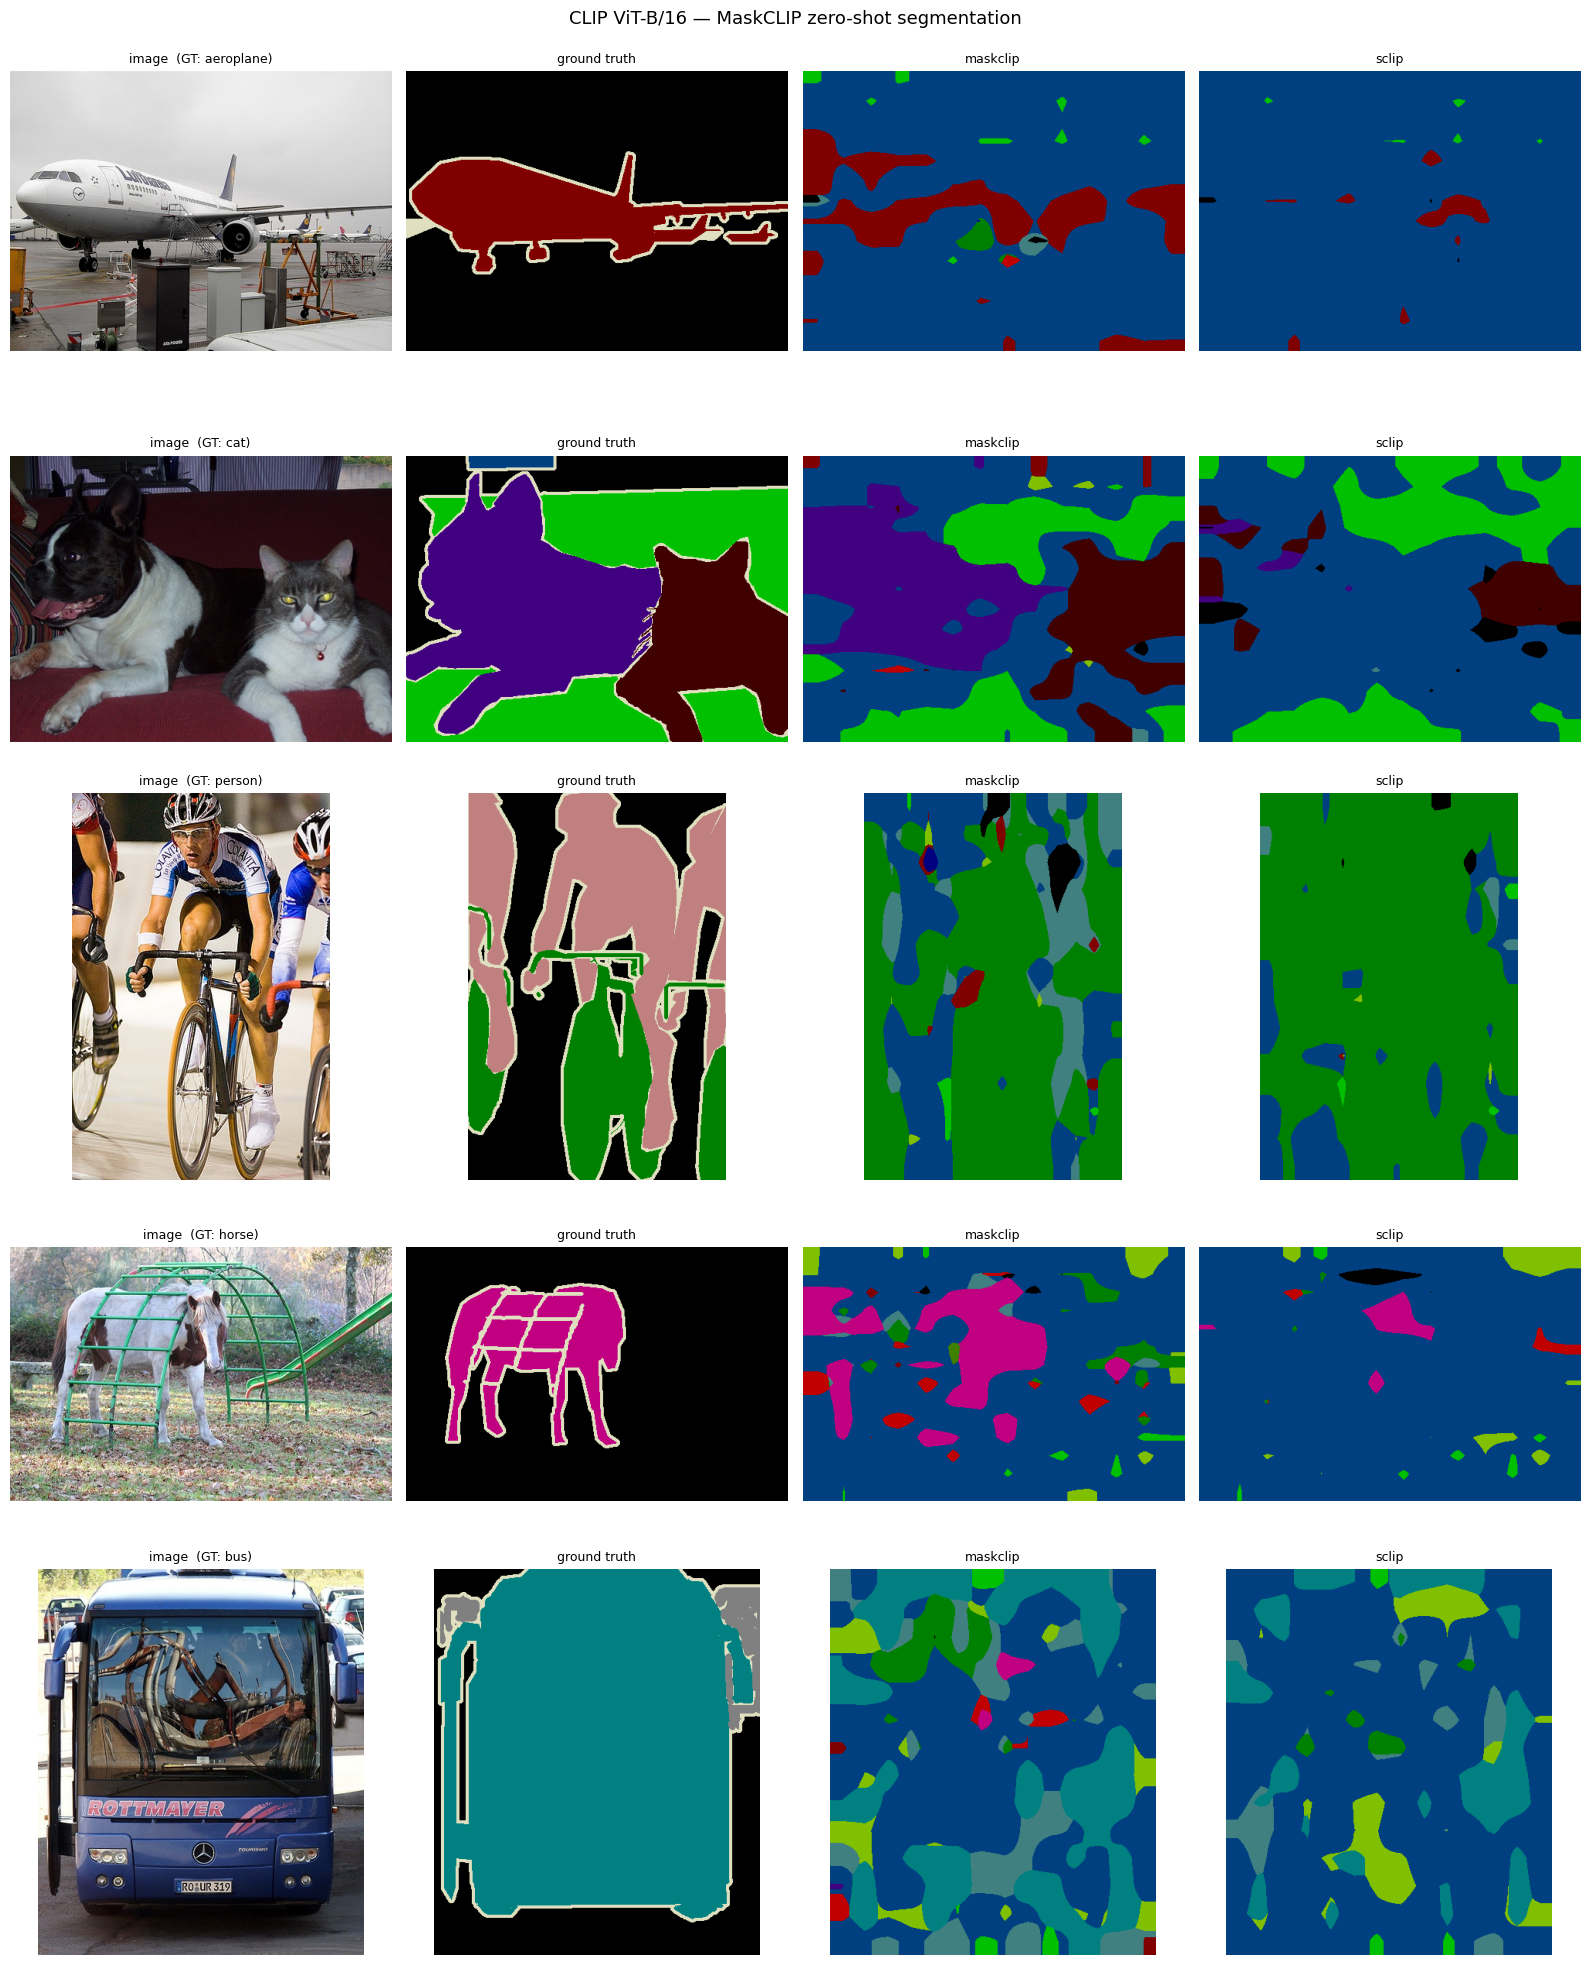

In [10]:
# ── 10. Visualisation — GT vs predicted (maskclip) ───────────────────────────

VOC_COLORS = np.array([
    [  0,   0,   0], [128,   0,   0], [  0, 128,   0], [128, 128,   0],
    [  0,   0, 128], [128,   0, 128], [  0, 128, 128], [128, 128, 128],
    [ 64,   0,   0], [192,   0,   0], [ 64, 128,   0], [192, 128,   0],
    [ 64,   0, 128], [192,   0, 128], [ 64, 128, 128], [192, 128, 128],
    [  0,  64,   0], [128,  64,   0], [  0, 192,   0], [128, 192,   0],
    [  0,  64, 128],
], dtype=np.uint8)

def label_to_rgb(label_map):
    rgb = np.zeros((*label_map.shape, 3), dtype=np.uint8)
    for c, col in enumerate(VOC_COLORS):
        rgb[label_map == c] = col
    rgb[label_map == 255] = [224, 224, 192]
    return rgb

# Pick one image per selected class
SHOW_CLASSES = {
    'aeroplane': 1, 'cat': 8, 'person': 15, 'horse': 13, 'bus': 6
}

def first_image_with(voc, class_idx):
    for i in range(len(voc)):
        if class_idx in np.unique(np.array(voc[i][1])):
            return i

text_feats = encode_text_classes(model, processor, VOC_CLASSES, DEVICE)

fig, axes = plt.subplots(len(SHOW_CLASSES), 4,
                         figsize=(16, 4 * len(SHOW_CLASSES)))
fig.suptitle('CLIP ViT-B/16 — MaskCLIP zero-shot segmentation', fontsize=13)

for row, (cls_name, cls_idx) in enumerate(SHOW_CLASSES.items()):
    img_idx       = first_image_with(voc_val, cls_idx)
    pil_img, mask = voc_val[img_idx]
    orig_w, orig_h = pil_img.size

    pix = processor(images=pil_img, return_tensors='pt').pixel_values.to(DEVICE)

    axes[row, 0].imshow(pil_img)
    axes[row, 0].set_title(f'image  (GT: {cls_name})', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(label_to_rgb(np.array(mask)))
    axes[row, 1].set_title('ground truth', fontsize=9)
    axes[row, 1].axis('off')

    for col, method in enumerate(['maskclip', 'sclip'], start=2):
        pred = predict_segmentation(
            model, processor, pil_img, text_feats,
            method=method, tau_seg=best_tau,
            n_classes_fg=len(VOC_CLASSES), device=DEVICE
        )
        axes[row, col].imshow(label_to_rgb(pred))
        axes[row, col].set_title(method, fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

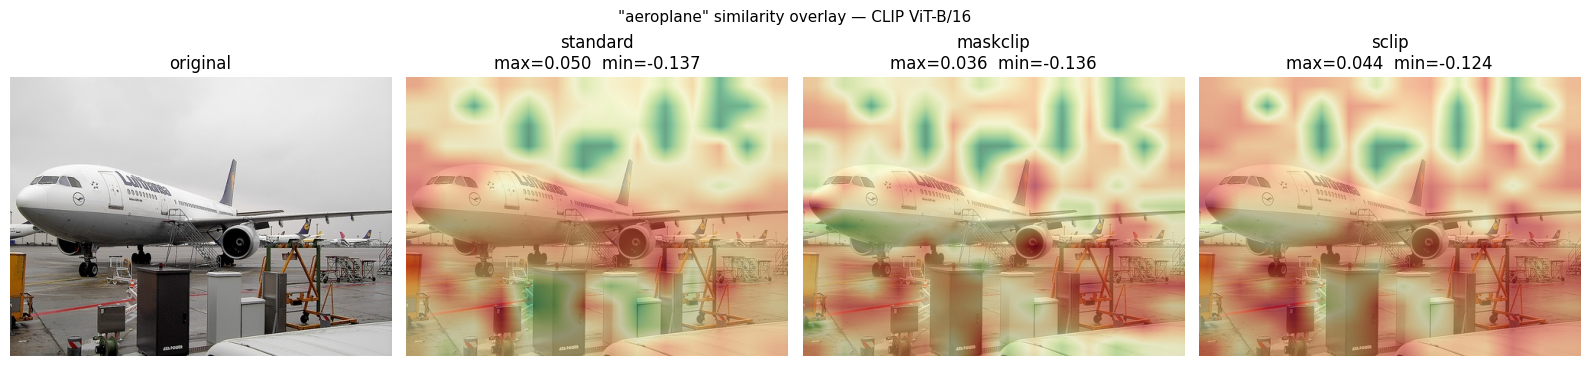

In [11]:
# ── 11. Aeroplane similarity overlay — CLIP vs SigLIP comparison ─────────────
# Shows the 'aeroplane' per-patch cosine similarity heatmap for CLIP (maskclip).
# Compare visually with the SigLIP version from 02b_segmentation_viz.ipynb.

pil_aero, _ = voc_val[0]
orig_w, orig_h = pil_aero.size
pix = processor(images=pil_aero, return_tensors='pt').pixel_values.to(DEVICE)
aero_idx = VOC_CLASSES.index('aeroplane')  # 0

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('"aeroplane" similarity overlay — CLIP ViT-B/16', fontsize=11)

axes[0].imshow(pil_aero)
axes[0].set_title('original')
axes[0].axis('off')

for col, method in enumerate(['standard', 'maskclip', 'sclip'], start=1):
    feats  = extract_patch_features(model, pix, method)   # (1, 196, 512)
    sim    = (feats[0] @ text_feats.T)[:, aero_idx]       # (196,)
    sim_hw = sim.reshape(N_SIDE, N_SIDE).cpu().float().numpy()

    sim_up = F.interpolate(
        torch.from_numpy(sim_hw).unsqueeze(0).unsqueeze(0),
        size=(orig_h, orig_w), mode='bilinear', align_corners=False
    ).squeeze().numpy()

    axes[col].imshow(pil_aero)
    axes[col].imshow(sim_up, cmap='RdYlGn', alpha=0.55)
    axes[col].set_title(f'{method}\nmax={sim_hw.max():.3f}  min={sim_hw.min():.3f}')
    axes[col].axis('off')

plt.tight_layout()
plt.show()